In [1]:
from pandas import read_csv
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.svm import SVC

In [2]:
df = read_csv("../../datasets/spambase.csv")

x = df[['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
       'word_freq_our', 'word_freq_over', 'word_freq_remove',
       'word_freq_internet', 'word_freq_order', 'word_freq_mail',
       'word_freq_receive', 'word_freq_will', 'word_freq_people',
       'word_freq_report', 'word_freq_addresses', 'word_freq_free',
       'word_freq_business', 'word_freq_email', 'word_freq_you',
       'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000',
       'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george',
       'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet',
       'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
       'word_freq_technology', 'word_freq_1999', 'word_freq_parts',
       'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting',
       'word_freq_original', 'word_freq_project', 'word_freq_re',
       'word_freq_edu', 'word_freq_table', 'word_freq_conference',
       'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!',
       'char_freq_$', 'char_freq_#', 'capital_run_length_average',
       'capital_run_length_longest', 'capital_run_length_total']].values

x = np.asarray(x)

y = np.asarray(df['spam'].values)

# x = preprocessing.StandardScaler().fit(x).transform(x)

x_train , x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=4)
print("training data: ", x_train.shape, y_train.shape)
print("testing data: ", x_test.shape, y_test.shape)


training data:  (3680, 57) (3680,)
testing data:  (921, 57) (921,)


In [3]:
kernels = ['poly', 'linear', 'rbf', 'sigmoid']  # , 'precomputed'

for kernel in kernels:
    clf = SVC(kernel=kernel, C=1)
    clf.fit(x_train, y_train)

    yhat = clf.predict(x_test)
    fs = metrics.f1_score(y_test, yhat)
    print(kernel, fs)

# c = 1, 'linear'

poly 0.22926829268292684
linear 0.9108910891089109
rbf 0.5165562913907285
sigmoid 0.5378378378378378


              precision    recall  f1-score   support

           0       0.94      0.95      0.94       562
           1       0.93      0.90      0.91       359

    accuracy                           0.93       921
   macro avg       0.93      0.93      0.93       921
weighted avg       0.93      0.93      0.93       921



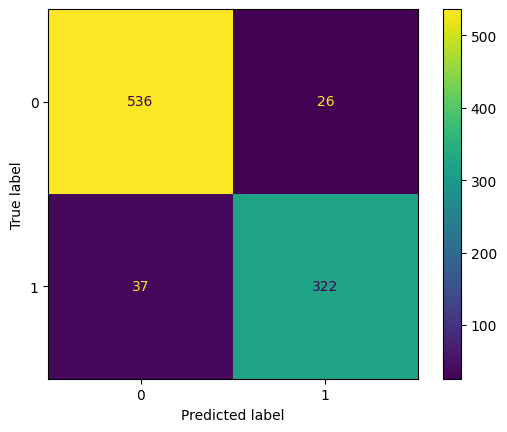

In [4]:
clf = SVC(kernel='linear', C=1).fit(x_train, y_train)

yhat = clf.predict(x_test)

print(metrics.classification_report(y_test, yhat))

cm = metrics.confusion_matrix(y_test, yhat)
disp = metrics.ConfusionMatrixDisplay(cm)
disp.plot()
